## **9 Comparação de modelos**

**Considerando o desbalanceamento da variável TARGET, a escolha do modelo não foi baseada apenas na acurácia. Foram considerados principalmente Precision, Recall, F1-score, ROC-AUC e PR-AUC para avaliar a capacidade de identificação dos clientes classificados como de maior risco.

Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho geral, com ROC-AUC de 0,74 e PR-AUC de 0,77, além de Precision de 0,73, Recall de 0,72 e F1-score de 0,72.

Embora o Gradient Boosting tenha apresentado valores ligeiramente superiores de Recall (0,74) e F1-score (0,73), o Random Forest apresentou desempenho superior nas métricas de discriminação geral e, principalmente, na PR-AUC, métrica particularmente relevante em cenários de classes desbalanceadas.

Dessa forma, o Random Forest foi selecionado como modelo final por apresentar o melhor equilíbrio entre capacidade de discriminação, precisão na identificação dos clientes de maior risco e desempenho sobre a classe minoritária..**

| Modelo           | Accur. |  Precision1 | Recall1 | F1 1 | ROC-AUC | PR-AUC|
| ---------------- | -----: |  ---------: | ------: | ---: | -----:  | -----:|
| Logistic Regres. | 0.53   |  0.59       | 0.54    | 0.57 | 0.54    | 0.60  |
| Decision Tree    | 0.56   |  0.59       | 0.75    | 0.66 | 0.55    | 0.60  |
| Random Forest    | 0.69   |  0.73       | 0.72    | 0.72 | 0.74    | 0.77  |
| Gradient Boost.  | 0.61   |  0.60       | 0.74    | 0.73 | 0.62    | 0.67  |




## 9. 1 Threshold (limiar): qual probablidade prevista no Random Forest vais ser o ponto de corte para ativar o Target.

In [ ]:
#Lista de precisão do modelo por probabilidade:
#Precision = % dos clientes considerados de maior risco pelo modelo que realmente são de maior risco
#Recall = % dos clientes de maior risco que realmente foram identificados (Se o objetivo do banco for não deixar passar maus pagadores, aceirar Recall maior mesmo que com menor Precision.)
#F1-score = métrica que busca medir o equilíbrio entre Precision e Recall.
thresholds = np.arange(0.10, 0.75, 0.05)

resultados_threshold = []

for threshold in thresholds:

    y_pred = (y_prob_rf >= threshold).astype(int)

    resultados_threshold.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

df_threshold = pd.DataFrame(resultados_threshold)

df_threshold

,Threshold,Precision,Recall,F1
0,0.10,0.623017,0.965069,0.757206
1,0.15,0.635370,0.952060,0.762125
2,0.20,0.647570,0.933992,0.764845
3,0.25,0.667555,0.905083,0.768381
4,0.30,0.678142,0.882679,0.767009
5,0.35,0.690243,0.848711,0.761318
6,0.40,0.695992,0.815707,0.751109
7,0.45,0.708719,0.775476,0.740596
8,0.50,0.729730,0.715490,0.722540
9,0.55,0.739719,0.658636,0.696827


\```
# Observações:
1- Após a seleção do Random Forest, foram avaliados diferentes valores de threshold para analisar o impacto do ponto de corte sobre Precision, Recall e F1-score.

O threshold de **0,10** foi selecionado com o objetivo de aumentar a capacidade de identificação dos clientes classificados como de maior risco. Nesse ponto de corte, o modelo alcançou **Recall de 96,5%**, indicando que consegue identificar a maior parte dos clientes pertencentes à classe de maior risco.

Decisão de negócio: essa escolha implica aceitar uma maior quantidade de falsos positivos e, consequentemente, uma possível redução da Precision. Em um contexto de análise de crédito, essa estratégia pode ser adequada quando o custo de deixar passar um cliente de maior risco é considerado superior ao custo de realizar uma análise adicional de clientes classificados preventivamente como de risco.
```

In [ ]:


importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = (
    importancias
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

importancias.head(10)

,Variavel,Importancia
0,AGE,0.229486
1,AMT_INCOME_TOTAL_LOG,0.168704
2,YEARS_EMPLOYED,0.157629
3,CNT_CHILDREN,0.040161
4,FLAG_OWN_CAR,0.026842
5,FLAG_PHONE,0.026302
6,FLAG_OWN_REALTY,0.026007
7,FLAG_WORK_PHONE,0.021822
8,OCCUPATION_TYPE_Not reported,0.015210
9,NAME_EDUCATION_TYPE_Secondary / secondary special,0.015199


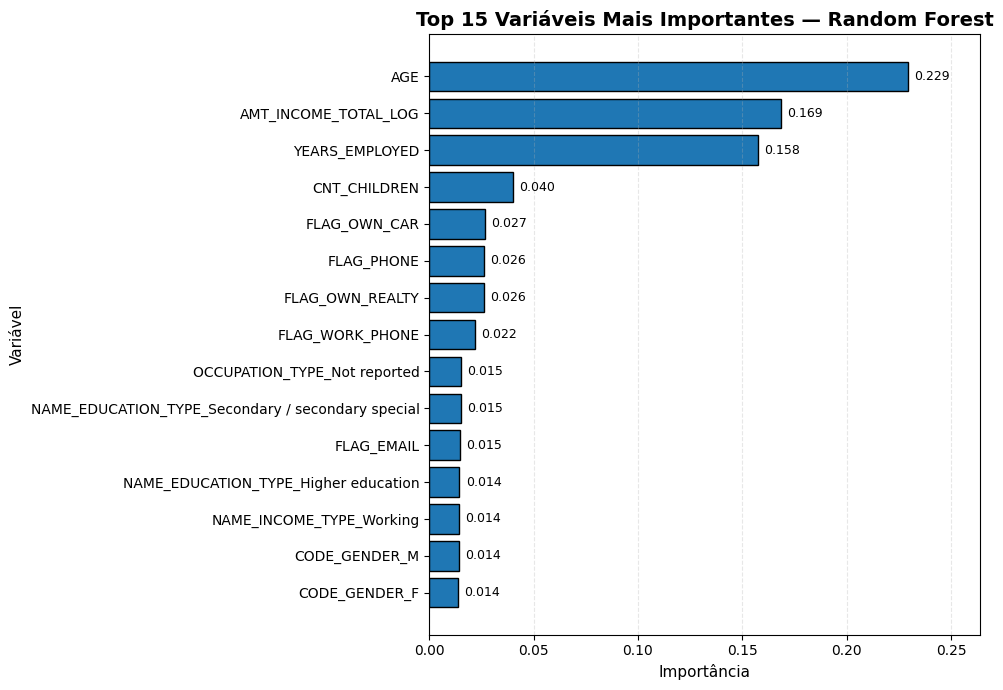

In [ ]:
#importância das variáveis
# Importância das variáveis - Random Forest

import pandas as pd
import matplotlib.pyplot as plt

# Criando DataFrame com as importâncias
importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

# Ordenando da maior para a menor importância
importancias = (
    importancias
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

# Selecionando as 15 mais importantes
top15 = importancias.head(15).sort_values('Importancia')

# Criando o gráfico
plt.figure(figsize=(10, 7))

barras = plt.barh(
    top15['Variavel'],
    top15['Importancia'],
    edgecolor='black'
)

# Adicionando os valores nas barras
for barra in barras:
    valor = barra.get_width()

    plt.text(
        valor + 0.003,
        barra.get_y() + barra.get_height() / 2,
        f'{valor:.3f}',
        va='center',
        fontsize=9
    )

plt.xlabel('Importância', fontsize=11)
plt.ylabel('Variável', fontsize=11)

plt.title(
    'Top 15 Variáveis Mais Importantes — Random Forest',
    fontsize=14,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.xlim(0, top15['Importancia'].max() * 1.15)

plt.tight_layout()
plt.show()

```

# Observações:
1- A análise da importância das variáveis do modelo Random Forest mostrou que
 as características com maior contribuição para a capacidade preditiva foram
 AGE (22,9%), AMT_INCOME_TOTAL_LOG (16,9%) e YEARS_EMPLOYED (15,8%). Em
 conjunto, essas três variáveis representam aproximadamente 55% da
 importância total atribuída pelo modelo.


CNT_CHILDREN (4,0%) e FLAG_PHONE (2,7%), com contribuições menores, porém
ainda relevantes para as decisões do modelo.

Os resultados sugerem, assim, que o perfil socioeconômico e a estabilidade
do solicitante são variáveis que apresentaram maior importância para as decisões preditivas do modelo
realizada pelo modelo.
```
